# Анализ повторных покупок: какие клиенты приносят больше всего прибыли (Когортный анализ и оценка LTV)

### Цель проекта
Проанализировать, какие клиенты возвращаются чаще и приносят больше денег. Найти точки роста для увелечения повторных продаж.

### Ключевые инсайты
1. **Бизнес растет:** средняя прибыль от клиента спустя 3 месяца выросла на 450 тыс. рублей за 3 месяца (январь - март).
2. **Лучшие клиенты (март 2026):** чаще всего возвращаются и больше всего приносят денег.
3. **Аномалия апреля:** клиенты реже всего возвращаются после покупки, но принесли больше всего денег за все время.
4. **Точка роста:** только 33% клиентов возвращаются после первой покупки. Стоит сфокусироваться на попытках улучшить первый опыт клиентов.

### Рекомендации
1. Проанализировать апрельских клиентов, чтобы понять, откуда они, почему покупают много, но редко возвращаются. Проверить маркетинговые каналы.
2. Понять, в чем успех работы с мартовскими клиентами и привлечь похожих.
3. Протестировать гипотезу с улучшением первого впечатления: приветственное письмо, чек-лист в коробке, скидка на вторую покупку или что-то другое. Запустить тест на одной категории товаров или на ограниченной выборке клиентов, чтобы оценить, возвращаются ли клиенты чаще или нет.
4. Взять на карандаш июньских клиентов: проверить, вернутся ли они через 1-2 месяца. Если да, то это новая "золотая жила", на которую стоит обратить повышенное внимание. Если нет - просто разовый всплеск.

In [95]:
import pandas as pd
import numpy as np
import random
import calendar
from datetime import datetime, timedelta
from IPython.display import Markdown, display

# Создание реалистичного датасета
np.random.seed(42)
random.seed(42)

start_date = datetime(2026, 1, 1)
end_date = datetime(2026, 6, 30)

customers = [f"CUST_{str(i).zfill(4)}" for i in range(1, 1501)]

transactions = []
transaction_id = 1000

retention_rates = [1.0, 0.32, 0.18, 0.11, 0.07, 0.04]

cohort_sizes = {
    '2026-01': 180,
    '2026-02': 210,
    '2026-03': 240,
    '2026-04': 260,
    '2026-05': 290,
    '2026-06': 320,
}

for cohort_month, cohort_size in cohort_sizes.items():
    year, month = map(int, cohort_month.split('-'))
    cohort_start = datetime(year, month, 1)
    available_customers = [c for c in customers if c not in [t['customer_id'] for t in transactions]]
    cohort_customers = random.sample(available_customers, min(cohort_size, len(available_customers)))
    
    for cust in cohort_customers:
        # Первая покупка (Month 0)
        days_in_month = calendar.monthrange(year, month)[1]
        first_purchase_day = random.randint(1, min(20, days_in_month))
        first_purchase_date = cohort_start + timedelta(days=first_purchase_day-1)
        
        revenue = round(random.lognormvariate(7.8, 0.9), 2)
        
        transactions.append({
            'transaction_id': transaction_id,
            'customer_id': cust,
            'transaction_date': first_purchase_date,
            'revenue': revenue
        })
        transaction_id += 1
        
        returned_in_previous_month = True
        
        for month_offset in range(1, 7):
            return_month = month + month_offset
            if return_month > 6:
                break
            
            if not returned_in_previous_month:
                break
            prob_return = retention_rates[month_offset] / retention_rates[month_offset - 1]
            
            if random.random() < prob_return:
                returned_in_previous_month = True
                
                days_in_return_month = calendar.monthrange(year, return_month)[1]
                return_day = random.randint(1, days_in_return_month)
                return_date = datetime(year, return_month, return_day)
                
                revenue = round(random.lognormvariate(7.8, 0.9), 2)
                
                transactions.append({
                    'transaction_id': transaction_id,
                    'customer_id': cust,
                    'transaction_date': return_date,
                    'revenue': revenue
                })
                transaction_id += 1
            else:
                returned_in_previous_month = False

df = pd.DataFrame(transactions)
df = df.sort_values(by=['customer_id', 'transaction_date']).reset_index(drop=True)

# Создаем когорты
df['transaction_month'] = df['transaction_date'].dt.to_period('M')
cohort_data = df.groupby('customer_id')['transaction_date'].min()
df['cohort_month'] = df['customer_id'].map(cohort_data.dt.to_period('M'))
df['cohort_index'] = (df['transaction_month'] - df['cohort_month']).apply(lambda x: x.n)

# Группируем по когорте и индексу, считаем уникальных клиентов
cohort_counts = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()

# Создаем сводную таблицу
cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_id')
cohort_pivot.columns = [f'Month {i}' for i in cohort_pivot.columns]

df_cohort1 = cohort_pivot.rename(columns={
    'Month 0': 'Старт (1-ый месяц)',
    'Month 1': 'Спустя 1 месяц',
    'Month 2': 'Спустя 2 месяца',
    'Month 3': 'Спустя 3 месяца',
    'Month 4': 'Спустя 4 месяца',
    'Month 5': 'Спустя 5 месяцев'
})

df_cohort1.index.name = 'Месяц привлечения'

display(Markdown('### Количество клиентов, пользующихся продуктом по месяцу привлечения спустя время'))
display(Markdown('*Примечание: В этой и последующих таблицах появляются значения nan. Это значит, что группа клиентов по месяцу привлечения еще не достигла срока жизненного цикла, указанного в столбце.*'))
display(df_cohort1.style
    .format('{:.0f}')
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))

### Количество клиентов, пользующихся продуктом по месяцу привлечения спустя время

*Примечание: В этой и последующих таблицах появляются значения nan. Это значит, что группа клиентов по месяцу привлечения еще не достигла срока жизненного цикла, указанного в столбце.*

,Старт (1-ый месяц),Спустя 1 месяц,Спустя 2 месяца,Спустя 3 месяца,Спустя 4 месяца,Спустя 5 месяцев
Месяц привлечения,,,,,,
2026-01,180,58,28,16,10,4
2026-02,210,72,43,27,19,nan
2026-03,240,85,47,23,nan,nan
2026-04,260,83,50,nan,nan,nan
2026-05,290,97,nan,nan,nan,nan
2026-06,320,nan,nan,nan,nan,nan


In [96]:
# Посчитаем процент удержания клиентов
cohort_sizes = cohort_pivot['Month 0']
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

retention_matrix = (retention_matrix * 100).round(1)

df_retention = retention_matrix.rename(columns={
    'Month 0': 'Старт (1-ый месяц)',
    'Month 1': 'Спустя 1 месяц',
    'Month 2': 'Спустя 2 месяца',
    'Month 3': 'Спустя 3 месяца',
    'Month 4': 'Спустя 4 месяца',
    'Month 5': 'Спустя 5 месяцев'
})

df_retention.index.name = 'Месяц привлечения'

def format_percent(value):
    if pd.isna(value):
        return 'nan'
    else:
        return f'{value:.1f}%'

display(Markdown('### Процент удержания клиентов'))
display(df_retention.style
    .format(format_percent)
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))

### Процент удержания клиентов

,Старт (1-ый месяц),Спустя 1 месяц,Спустя 2 месяца,Спустя 3 месяца,Спустя 4 месяца,Спустя 5 месяцев
Месяц привлечения,,,,,,
2026-01,100.0%,32.2%,15.6%,8.9%,5.6%,2.2%
2026-02,100.0%,34.3%,20.5%,12.9%,9.0%,nan
2026-03,100.0%,35.4%,19.6%,9.6%,nan,nan
2026-04,100.0%,31.9%,19.2%,nan,nan,nan
2026-05,100.0%,33.4%,nan,nan,nan,nan
2026-06,100.0%,nan,nan,nan,nan,nan


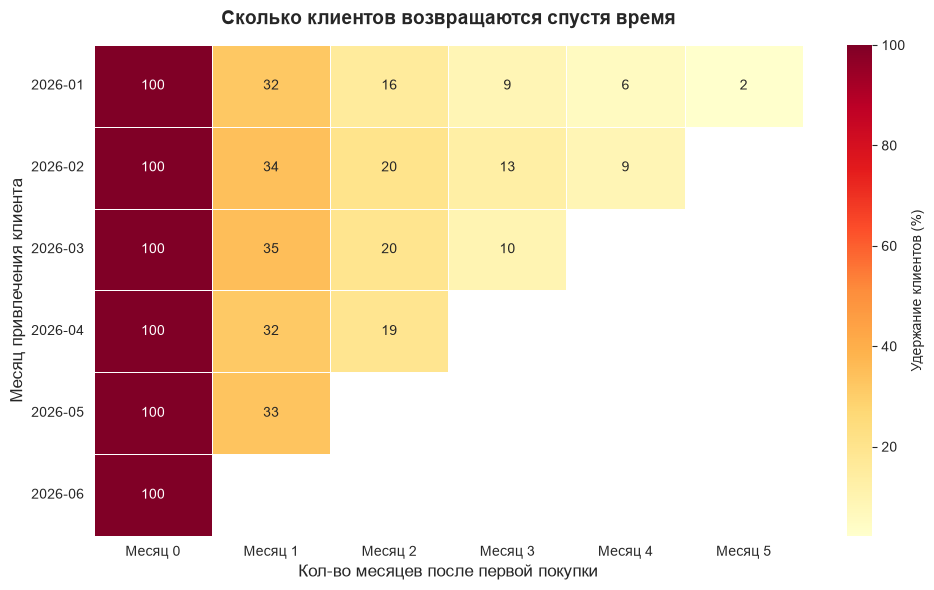

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

retention_matrix.columns = [f'Месяц {i}' for i in range(len(retention_matrix.columns))]

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Создаем тепловую карту
ax = sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Удержание клиентов (%)'},
    mask=np.isnan(retention_matrix)
)

# Оформляем график
plt.title('Сколько клиентов возвращаются спустя время', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Кол-во месяцев после первой покупки', fontsize=12)
plt.ylabel('Месяц привлечения клиента', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0)

plt.tight_layout()
plt.show()

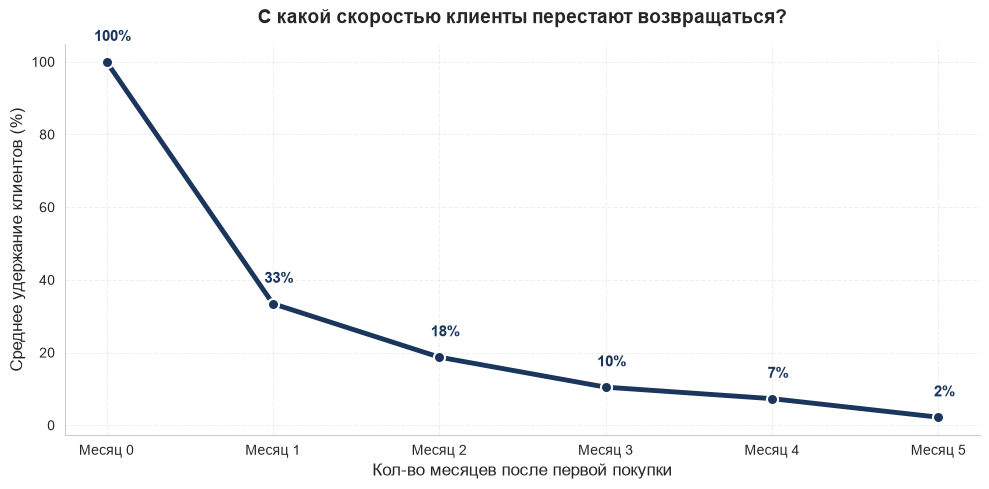

In [98]:
# Посчитаем средний процент удержания клиентов по всем когортам для каждого месяца
avg_retention = retention_matrix.mean(axis=0, skipna=True)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
russian_months = [f'Месяц {i}' for i in range(len(avg_retention))]

plt.figure(figsize=(10, 5))

# Создаем график удержания клиентов
ax = sns.lineplot(
    x=russian_months,
    y=avg_retention.values,
    marker='o',
    linewidth=3.5,
    markersize=8,
    color='#1B365D',
    markerfacecolor='#1B365D', 
    markeredgecolor='white',
    markeredgewidth=1.5
)

for i, val in enumerate(avg_retention.values):
    ax.annotate(
        f'   {int(val)}%', 
        (i, val), 
        textcoords="offset points", 
        xytext=(0, 15),
        ha='center', 
        fontsize=11, 
        fontweight='bold', 
        color='#1B365D'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Оформляем график
plt.title('С какой скоростью клиенты перестают возвращаться?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Кол-во месяцев после первой покупки', fontsize=12)
plt.ylabel('Среднее удержание клиентов (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [99]:
# Посчитаем суммарную выручку для каждой когорты
cohort_revenue = df.groupby(['cohort_month', 'cohort_index'])['revenue'].sum().reset_index()

revenue_pivot = cohort_revenue.pivot(index='cohort_month', columns='cohort_index', values='revenue')
revenue_pivot.columns = [f'Month {i}' for i in revenue_pivot.columns]
revenue_pivot = revenue_pivot.fillna(0)

ltv_pivot = revenue_pivot.cumsum(axis=1).round(0)

mask = cohort_pivot.isna()
ltv_pivot[mask] = np.nan

df_ltv = ltv_pivot.rename(columns={
    'Month 0': 'Старт (1-ый месяц)',
    'Month 1': 'Спустя 1 месяц',
    'Month 2': 'Спустя 2 месяца',
    'Month 3': 'Спустя 3 месяца',
    'Month 4': 'Спустя 4 месяца',
    'Month 5': 'Спустя 5 месяцев'
})

df_ltv.index.name = 'Месяц привлечения'
df_ltv = (df_ltv / 1000).round(1)

from IPython.display import Markdown, display

display(Markdown('### Суммарная выручка от всех клиентов спустя время (данные указаны в тыс. рублей)'))
display(df_ltv.style
    .format('{:.1f}')
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))

### Суммарная выручка от всех клиентов спустя время (данные указаны в тыс. рублей)

,Старт (1-ый месяц),Спустя 1 месяц,Спустя 2 месяца,Спустя 3 месяца,Спустя 4 месяца,Спустя 5 месяцев
Месяц привлечения,,,,,,
2026-01,650.7,838.8,952.1,1019.6,1038.9,1056.0
2026-02,717.3,999.7,1152.2,1274.4,1329.0,nan
2026-03,888.4,1198.0,1386.8,1469.1,nan,nan
2026-04,1021.4,1323.2,1538.5,nan,nan,nan
2026-05,942.7,1276.8,nan,nan,nan,nan
2026-06,1168.6,nan,nan,nan,nan,nan


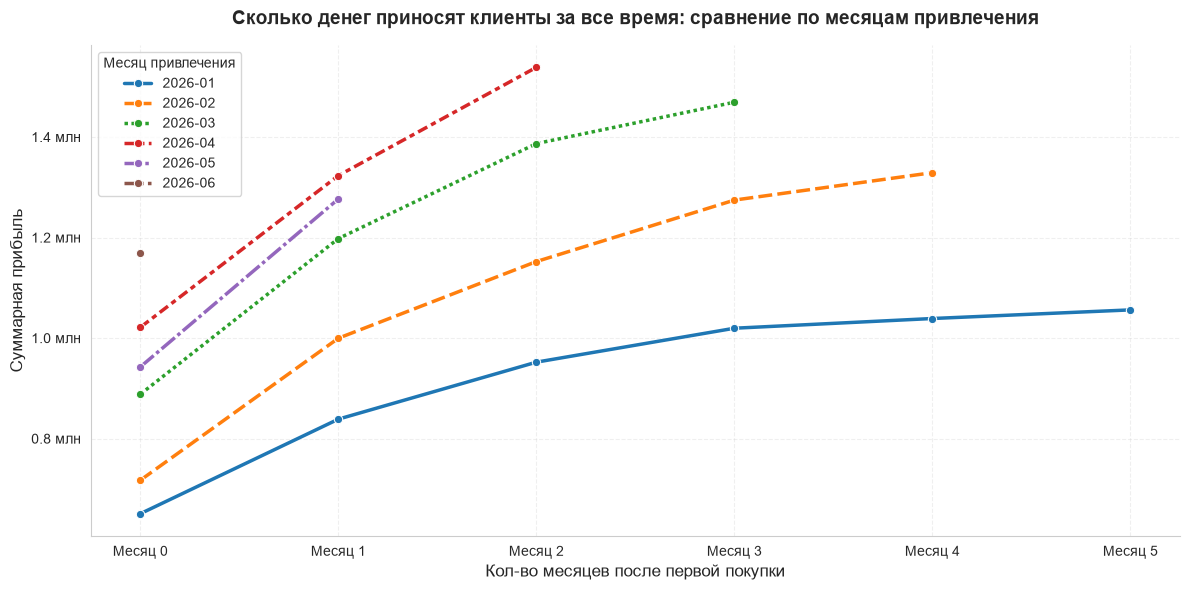

In [100]:
from matplotlib.ticker import FuncFormatter

# Построим график накопительного LTV по когортам 
ltv_plot_data = ltv_pivot.T

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=ltv_plot_data,
    marker='o',
    linewidth=2.5,
    markersize=6,
    palette='tab10'
)


# Немного визуальной работы над графиком
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f} млн'))

ax.set_title('Сколько денег приносят клиенты за все время: сравнение по месяцам привлечения', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Кол-во месяцев после первой покупки', fontsize=12)
ax.set_ylabel('Суммарная прибыль', fontsize=12)

ax.set_xticks(range(len(ltv_plot_data)))
ax.set_xticklabels([f'Месяц {i}' for i in range(len(ltv_plot_data))])
ax.legend(title='Месяц привлечения', loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [101]:
# Отсортируем когорты по удержанию клиента после месяца пользования и по LTV после третьего месяца
retention_ranking = pd.DataFrame({
    'Удержание после 1-го месяца (%)': retention_matrix['Месяц 1']
}).round(1).sort_values(by='Удержание после 1-го месяца (%)', ascending=False)

retention_ranking.index.name = 'Месяц привлечения'

def format_percent(value):
    if pd.isna(value):
        return 'NaN'
    else:
        return f'{value:.1f}%'

def format_number(value):
    if pd.isna(value):
        return 'NaN'
    else:
        return f'{value:,.0f}'

display(Markdown('### Рейтинг по удержанию после первого месяца'))
display(retention_ranking.style
    .format({'Удержание после 1-го месяца (%)': format_percent})
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))

ltv_ranking = pd.DataFrame({
    'Суммарная прибыль после трех месяцев': ltv_pivot['Month 3']
}).round(0).sort_values(by='Суммарная прибыль после трех месяцев', ascending=False)

ltv_ranking.index.name = 'Месяц привлечения'

display(Markdown('### Рейтинг по суммарной прибыли после третьего месяца'))
display(ltv_ranking.style
    .format({'Суммарная прибыль после трех месяцев': format_number})
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '10pt')]}]))

### Рейтинг по удержанию после первого месяца

,Удержание после 1-го месяца (%)
Месяц привлечения,
2026-03,35.4%
2026-02,34.3%
2026-05,33.4%
2026-01,32.2%
2026-04,31.9%
2026-06,NaN


### Рейтинг по суммарной прибыли после третьего месяца

,Суммарная прибыль после трех месяцев
Месяц привлечения,
2026-03,"1,469,106"
2026-02,"1,274,429"
2026-01,"1,019,556"
2026-04,NaN
2026-05,NaN
2026-06,NaN
